# **AdaBoost Applied to Real Projects — Classification & Regression**

This notebook applies `AdaBoostClassifier` and `AdaBoostRegressor` to the **same two projects** used
for Random Forest earlier:
1. **Holiday Package Prediction** (classification) — `03_Project_HolidayPackage_RandomForest_Classification.ipynb`
2. **Car Price Prediction** (regression) — `04_Project_CarPrice_RandomForest_Regression.ipynb`

**Why reuse the same projects?** Testing a new algorithm on a problem you already know well (with
feature engineering already done) isolates the comparison to just the *algorithm* — the fairest way to
judge whether AdaBoost is a good fit.



# **Part A — AdaBoost for Classification (Holiday Package Prediction)**


### **A.1 Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              roc_auc_score, roc_curve)

np.random.seed(42)


## **A.2  Holiday Package Dataset**

In [2]:
df = pd.read_csv("Travel.csv")
df['Gender'] = df['Gender'].replace('Fe Male', 'Female')
df['MaritalStatus'] = df['MaritalStatus'].replace('Single', 'Unmarried')
features_with_na = [f for f in df.columns if df[f].isnull().sum() >= 1]

# Impute (fill) missing values in each column
for f in features_with_na:
    if not pd.api.types.is_numeric_dtype(df[f]):
        df[f] = df[f].fillna(df[f].mode()[0])
    else:
        df[f] = df[f].fillna(df[f].median())
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [3]:
df.drop('CustomerID', axis=1, inplace=True)
df['TotalVisiting'] = (df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting'])
df.drop(['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'],axis=1,inplace=True)
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


### **A.3 Train-Test Split & Preprocessing (same ColumnTransformer pattern as Holiday Package RandomForest Classification)**

In [4]:
X = df.drop('ProdTaken', axis=1)
y = df['ProdTaken']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

cat_features = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
num_features = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]

preprocessor = ColumnTransformer(transformers=[
    ('OneHotEncoder', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features),
    ('StandardScaler', StandardScaler(), num_features)
])

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Train:", X_train_transformed.shape, " Test:", X_test_transformed.shape)


Train: (3910, 26)  Test: (978, 26)


## **A.4 Train & Compare: Logistic Regression, Decision Tree, Random Forest, AdaBoost**

This is the same reusable loop pattern used throughout this series — adding `AdaBoostClassifier` is
just one more dictionary entry.

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),   # default: 50 stumps, learning_rate=1.0
}

results = []
for name, model in models.items():
    model.fit(X_train_transformed, y_train)
    y_pred = model.predict(X_test_transformed)
    # These probabilities are used to compute the ROC-AUC Score.
    y_train_prob = model.predict_proba(X_train_transformed)[:, 1]
    y_test_prob = model.predict_proba(X_test_transformed)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "F1": round(f1_score(y_test, y_pred), 3),
        "Precision": round(precision_score(y_test, y_pred), 3),
        "Recall": round(recall_score(y_test, y_pred), 3),
        "Train ROC-AUC": roc_auc_score(y_train, y_train_prob),
        # ROC-AUC Score on the testing dataset
        # Measures how well the model separates the two classes.
        "Test ROC-AUC": roc_auc_score(y_test, y_test_prob)
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
results_df


,Model,Accuracy,F1,Precision,Recall,Train ROC-AUC,Test ROC-AUC
2,Random Forest,0.939,0.809,0.977,0.690,1.000000,0.961618
1,Decision Tree,0.912,0.756,0.792,0.723,1.000000,0.839373
0,Logistic Regression,0.831,0.363,0.627,0.255,0.823592,0.768782
3,AdaBoost,0.837,0.335,0.727,0.217,0.835200,0.772321


## **A.5 Hyperparameter Tuning AdaBoost**

We tune `n_estimators` (number of sequential stumps) and `learning_rate` (how much each stump's
correction shrinks/grows the next round's weights) using the same `RandomizedSearchCV` pattern
established for Random Forest.

In [6]:
adaboost_params = {
    "n_estimators": [50, 60, 70, 80, 90],
    "learning_rate": [0.5, 0.8, 1.0, 1.2],
}

random_search = RandomizedSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_distributions=adaboost_params,
    n_iter=15,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_transformed, y_train)

print("Best AdaBoost Parameters:", random_search.best_params_)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best AdaBoost Parameters: {'n_estimators': 80, 'learning_rate': 0.8}


## A.6 Final Comparison — AdaBoost (tuned) vs Random Forest, via ROC-AUC

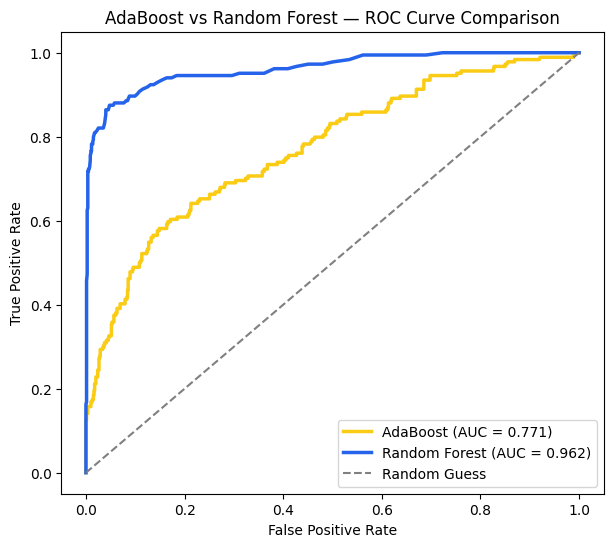

AdaBoost AUC: 0.7709
Random Forest AUC: 0.9616


In [7]:
best_ada = random_search.best_estimator_

rf = RandomForestClassifier(random_state=42, n_estimators=200)
rf.fit(X_train_transformed, y_train)

ada_prob = best_ada.predict_proba(X_test_transformed)[:, 1]
rf_prob = rf.predict_proba(X_test_transformed)[:, 1]

ada_auc = roc_auc_score(y_test, ada_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost (AUC = {ada_auc:.3f})", color="#facc15", linewidth=2.5)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_auc:.3f})", color="#2563eb", linewidth=2.5)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AdaBoost vs Random Forest — ROC Curve Comparison")
plt.legend()
plt.show()

print(f"AdaBoost AUC: {ada_auc:.4f}")
print(f"Random Forest AUC: {rf_auc:.4f}")



---
# **Part B — AdaBoost for Regression (Car Price Prediction)**


## B.1 Imports

In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(7)


## B.2 Recreate the Synthetic Car Price Dataset (same as Notebook 04)

In [9]:
df2 = pd.read_csv(r"cardekho_imputated.csv", index_col=[0])
df2.drop(['car_name', 'brand'], axis=1, inplace=True)
df2.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


## B.3 Feature Engineering (same pattern as Notebook 04: Label Encoding + One-Hot + passthrough)

In [10]:
X2 = df2.drop('selling_price', axis=1)
y2 = df2['selling_price']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

label_encoder = LabelEncoder()
label_encoder.fit(X2_train['model'])
known_models = set(label_encoder.classes_)

X2_train = X2_train.copy()
X2_test = X2_test.copy()
X2_train['model'] = label_encoder.transform(X2_train['model'])
X2_test['model'] = X2_test['model'].apply(lambda v: v if v in known_models else label_encoder.classes_[0])
X2_test['model'] = label_encoder.transform(X2_test['model'])

onehot_columns = ['seller_type', 'fuel_type', 'transmission_type']
numeric_columns = [c for c in X2.columns if pd.api.types.is_numeric_dtype(X2[c]) and c != 'model']

preprocessor2 = ColumnTransformer(transformers=[
    ('OneHotEncoder', OneHotEncoder(drop='first', handle_unknown='ignore'), onehot_columns),
    ('StandardScaler', StandardScaler(), numeric_columns)
], remainder='passthrough')

X2_train_t = preprocessor2.fit_transform(X2_train)
X2_test_t = preprocessor2.transform(X2_test)

print("Train:", X2_train_t.shape, " Test:", X2_test_t.shape)


Train: (12328, 14)  Test: (3083, 14)


## B.4 Train & Compare: Linear/Ridge/Lasso, KNN, Decision Tree, Random Forest, AdaBoost

In [11]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predicted)
    return mae, mse, rmse, r2

reg_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42, n_jobs=-1),
    "AdaBoost Regressor": AdaBoostRegressor(random_state=42),   # default base: depth-3 Decision Tree
}

reg_results = []
for name, model in reg_models.items():
    model.fit(X2_train_t, y2_train)
    ytr_pred = model.predict(X2_train_t)
    yte_pred = model.predict(X2_test_t)
    _, _, _, train_r2 = evaluate_model(y2_train, ytr_pred)
    test_mae, test_mse, test_rmse, test_r2 = evaluate_model(y2_test, yte_pred)
    reg_results.append({
        "Model": name, "Train R2": round(train_r2, 3), "Test R2": round(test_r2, 3),
        "Test MAE": round(test_mae, 0),
    })

reg_results_df = pd.DataFrame(reg_results).sort_values("Test R2", ascending=False)
reg_results_df


,Model,Train R2,Test R2,Test MAE
5,Random Forest Regressor,0.973,0.935,100801.0
3,K-Neighbors Regressor,0.883,0.900,109866.0
4,Decision Tree,0.999,0.877,125239.0
6,AdaBoost Regressor,0.770,0.721,340496.0
2,Lasso,0.622,0.665,279568.0
0,Linear Regression,0.622,0.665,279572.0
1,Ridge,0.622,0.665,279511.0


## B.5 Hyperparameter Tuning AdaBoost Regressor

We tune `n_estimators` and `loss` (`linear` / `square` / `exponential` — controls how aggressively
larger errors get penalized when updating weights each round).

In [12]:
adaboost_reg_params = {
    "n_estimators": [50, 60, 70, 80],
    "loss": ["linear", "square", "exponential"],
}

random_search_reg = RandomizedSearchCV(
    estimator=AdaBoostRegressor(random_state=42),
    param_distributions=adaboost_reg_params,
    n_iter=12,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search_reg.fit(X2_train_t, y2_train)

print("Best AdaBoost Regressor Parameters:", random_search_reg.best_params_)

best_ada_reg = random_search_reg.best_estimator_
_, _, _, train_r2 = evaluate_model(y2_train, best_ada_reg.predict(X2_train_t))
_, _, _, test_r2 = evaluate_model(y2_test, best_ada_reg.predict(X2_test_t))
print(f"Tuned AdaBoost Regressor -> Train R2: {train_r2:.3f} | Test R2: {test_r2:.3f}")
print("\nImportant lesson: tuning does NOT always improve test performance —")
print("RandomizedSearchCV only explores a random subset of the parameter grid,")
print("so compare this to the untuned AdaBoost Regressor row in the table above!")


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best AdaBoost Regressor Parameters: {'n_estimators': 50, 'loss': 'linear'}
Tuned AdaBoost Regressor -> Train R2: 0.770 | Test R2: 0.721

Important lesson: tuning does NOT always improve test performance —
RandomizedSearchCV only explores a random subset of the parameter grid,
so compare this to the untuned AdaBoost Regressor row in the table above!



- Newer scikit-learn versions **removed** `AdaBoostClassifier`'s `algorithm` parameter — use
  `learning_rate` instead when tuning.
- Hyperparameter tuning is a **search, not a guarantee** — `RandomizedSearchCV` can occasionally
  land on parameters that perform worse on held-out test data than the defaults.
- Trying every algorithm on the same, already-prepared dataset is standard practice — it's the
  fastest way to find out what actually works best for your specific problem.
